In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data_train = pd.read_csv("feature-engineering-train.csv")
data_test = pd.read_csv("feature-engineering-test.csv")

X_train, y_train = data_train.drop(columns=["label"]), data_train["label"]
X_test, y_test = data_test.drop(columns=["label"]), data_test["label"]

X = pd.concat((X_train, X_test), axis=0)
y = pd.concat((y_train, y_test), axis=0)

In [3]:
from functools import reduce

binary_columns = [col for col in X.columns if col.startswith("B")]
discrete_columns = [col for col in X.columns if col.startswith("D")]
float_columns = [col for col in X.columns if col.startswith("F")]
object_columns = [col for col in X.columns if col.startswith("O")]

columns = reduce(
    np.union1d,
    (
        binary_columns,
        discrete_columns,
        float_columns,
        object_columns,
    ),
)
np.setdiff1d(X.columns, columns)

array([], dtype=object)

# 1. Feature Selection

## 1.1. Mutual Information for Binary features

In [13]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X_train, y_train)
mi = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)
mi

DLineOfCode                 0.586449
DNoOfExternalRef            0.536070
DNoOfImage                  0.534821
DNoOfSelfRef                0.515901
DNoOfJS                     0.497235
DLargestLineLength          0.449763
DNoOfCSS                    0.442745
BHasSocialNet               0.393361
BHasCopyrightInfo           0.330742
BHasDescription             0.289045
FDomainTitleMatchScore      0.194574
BHasSubmitButton            0.191616
BIsResponsive               0.170839
DNoOfEmptyRef               0.169051
FURLTitleMatchScore         0.169035
DNoOfiFrame                 0.167167
BIsHTTPS                    0.163419
FDomainEntropy              0.156215
FCharContinuationRate       0.154651
BHasHiddenFields            0.146282
BHasFavicon                 0.145207
FURLCharProb                0.138216
FAlphabetRatioInDomain      0.133935
BHasTitle                   0.125930
FDigitRatioInDomain         0.107389
DNoOfDigitsInDomain         0.103843
DNoOfTokensInDomain         0.098993
D

Based on the results of MI regression, the most important binary features are

- `HasSocialNet`
- `HasCopyrightInfo`
- `HasDescription`
- `HasSubmitButton`

In [14]:
select_binary_columns = [col for col in mi.index if col.startswith("B")][:4]
select_binary_columns

['BHasSocialNet', 'BHasCopyrightInfo', 'BHasDescription', 'BHasSubmitButton']

## 1.2. Anova for floating point features

**Note:** We need to check for normality to apply ANOVA.

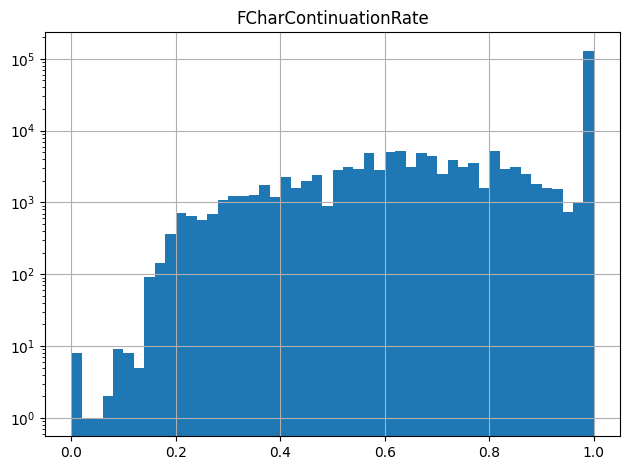

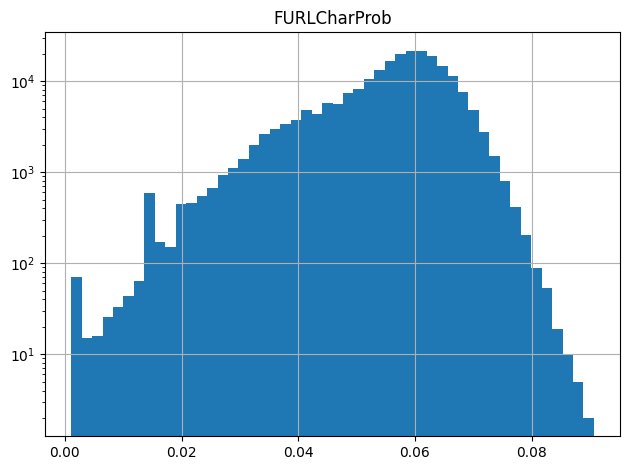

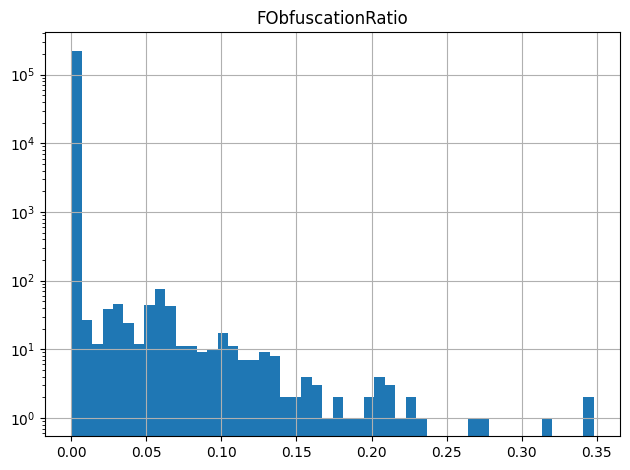

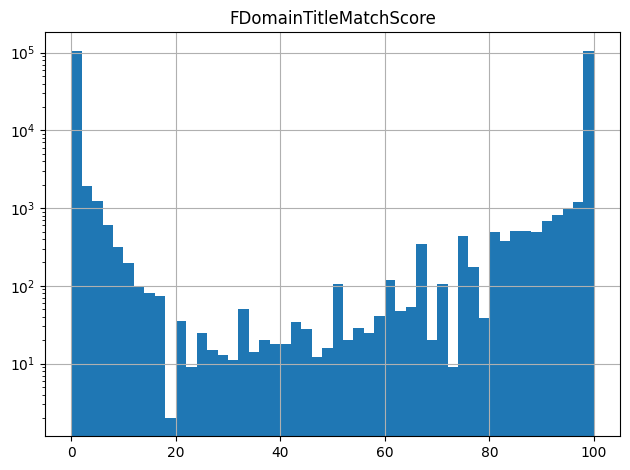

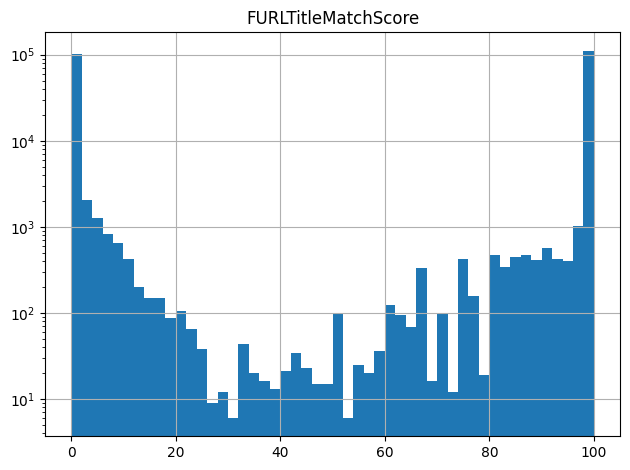

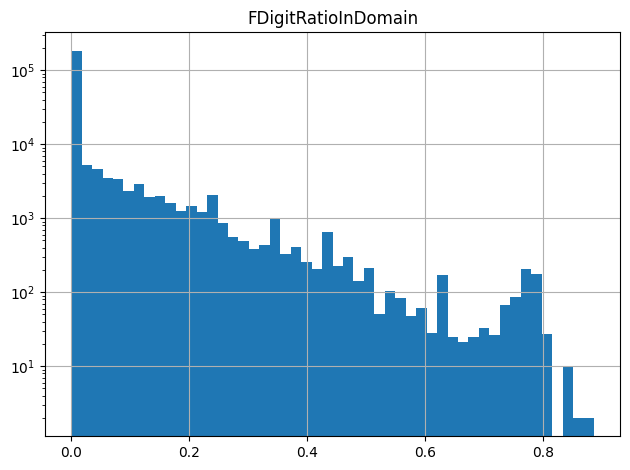

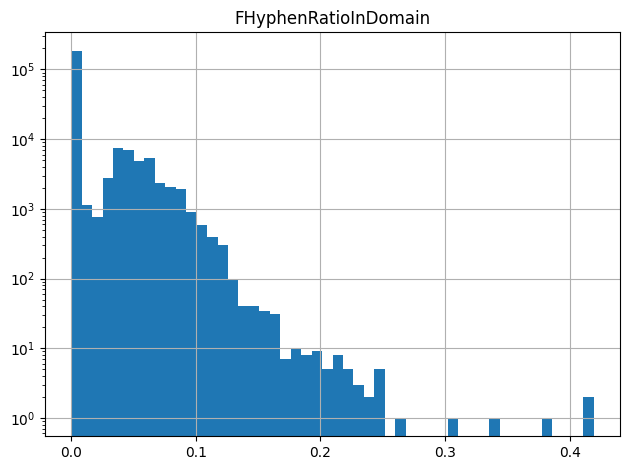

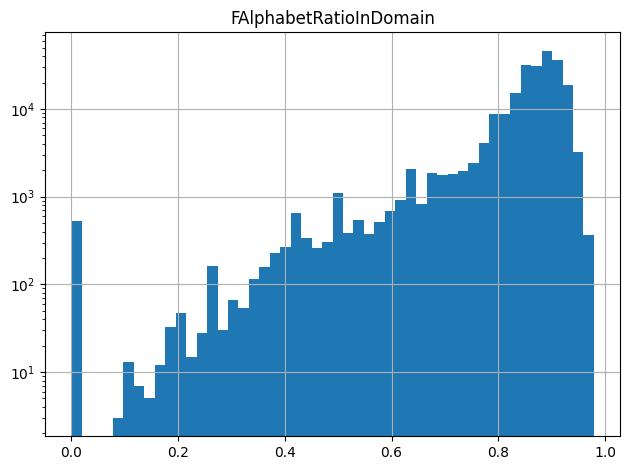

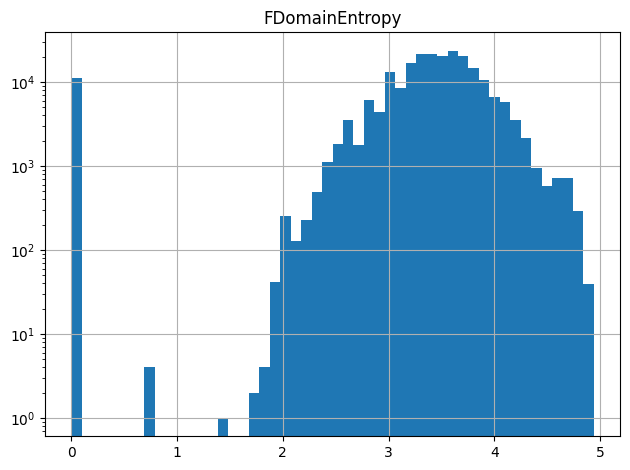

In [9]:
for col in float_columns:
    plt.figure()
    X[col].hist(bins=50, log=True)
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [5]:
from sklearn.feature_selection import f_classif

F, pvals = f_classif(X[float_columns], y.values)

pd.DataFrame(
    {
        "feature": float_columns,
        "F": F,
        "pval": pvals,
    }
).sort_values("pval")

,feature,F,pval
0,FCharContinuationRate,62991.716549,0.000000e+00
1,FURLCharProb,64620.639184,0.000000e+00
3,FDomainTitleMatchScore,116102.049971,0.000000e+00
4,FURLTitleMatchScore,92642.779420,0.000000e+00
6,FHyphenRatioInDomain,19677.963539,0.000000e+00
5,FDigitRatioInDomain,29408.879616,0.000000e+00
7,FAlphabetRatioInDomain,19517.045753,0.000000e+00
8,FDomainEntropy,3524.840832,0.000000e+00
2,FObfuscationRatio,393.171639,2.007389e-87


All of the columns have very low p-values (nearly zero). So, we keep all of the floating point columns.

## 1.3. Wrapper Method: RFE

**Note:** Takes too long.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, step=1)
rfe.fit(X_train, y_train)
pd.Series(rfe.ranking_, index=X_train.columns).sort_values(ascending=False)

/home/byron/Development/School/2025-1/STAT411/Phishing-URL--Website--Detection/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


KeyboardInterrupt: 

In [17]:
X_train.columns[rfe.get_support()]

Index(['FCharContinuationRate', 'DNoOfObfuscatedChar', 'BIsHTTPS', 'BHasTitle',
       'BHasDescription', 'BHasSocialNet', 'BHasCopyrightInfo',
       'FAlphabetRatioInDomain', 'DNoOfTokensInDomain', 'FDomainEntropy'],
      dtype='object')

## 1.4. Embedded Method: Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
importances = pd.Series(
    data=rf.feature_importances_,
    index=X_train.columns,
).sort_values()

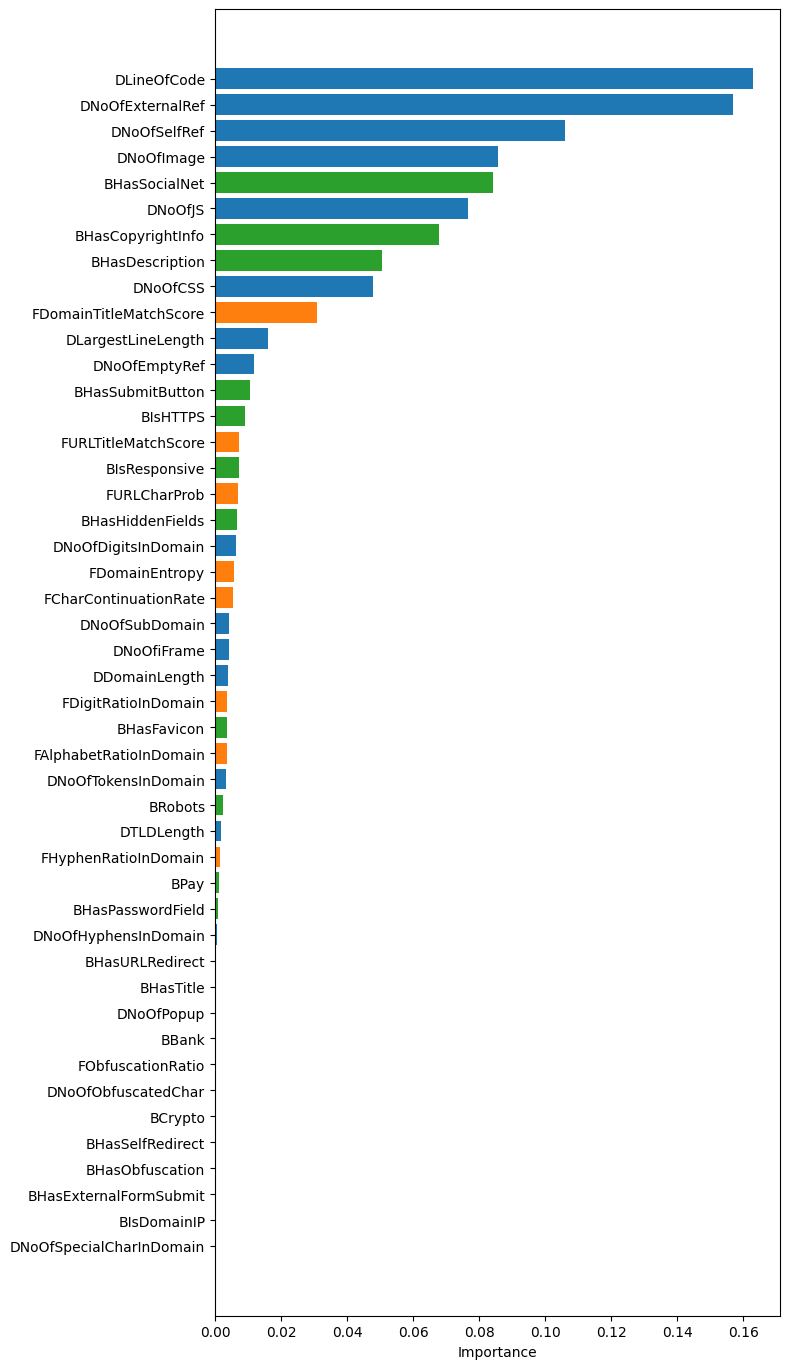

In [40]:
def feature_color(name):
    if name.startswith("D"):
        return "tab:blue"
    if name.startswith("F"):
        return "tab:orange"
    if name.startswith("B"):
        return "tab:green"
    return "gray"


plt.figure(figsize=(8, 0.3 * len(importances)))
plt.barh(
    importances.index,
    importances.values,
    color=[feature_color(f) for f in importances.index]
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()